# Example 05: Composite models — NMR quartet

`CompositeModel` fits a weighted sum of named components simultaneously, coupling all parameters through a shared covariance matrix. Simultaneous fitting is essential when spectral lines overlap: fitting peaks sequentially propagates errors from earlier subtractions into later estimates.

A J-coupled quartet — four Lorentzian lines with 1:3:3:1 binomial amplitudes at uniform spacing $J$ — is a natural test case. Outer lines are broader than inner lines, as expected in strongly coupled multiplets. The joint fit should recover amplitude ratios exactly and achieve the Cramér–Rao precision limit. NMR is used as a concrete example; the model itself is not domain-specific.

*Implementation: `CompositeModel` in [models/composite.py](../dftmodels/models/composite.py).*

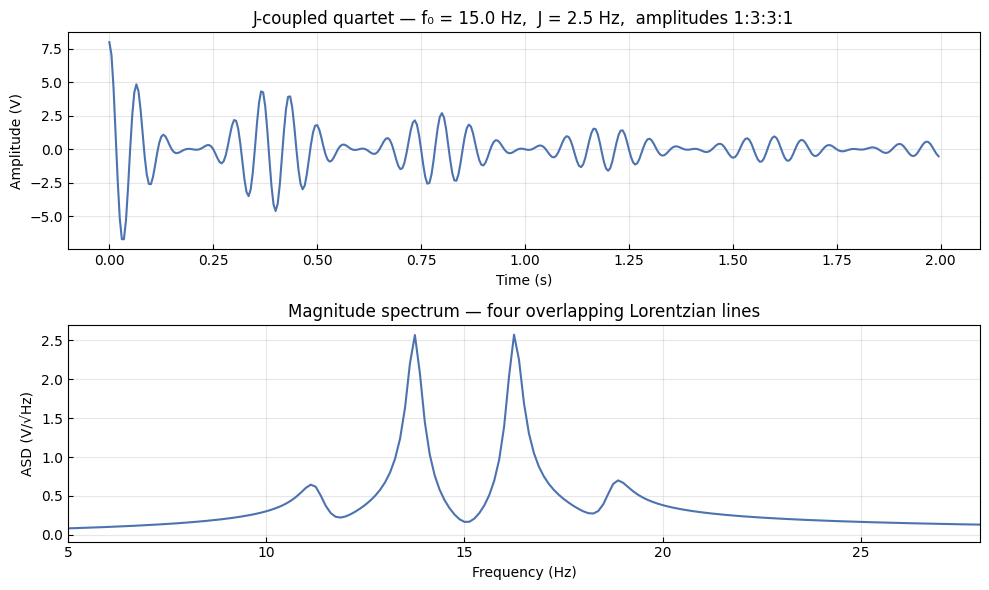

In [1]:
# Imports, constants, and quartet signal overview
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from pathlib import Path

Path("figures").mkdir(exist_ok=True)
plt.style.use("dftmodels.mplstyle")

from dftmodels import (
    SignalSeries, FourierSeries, NormType, WindowType, DFTRange,
    DFTCorrection, DFTCorrectionMode, Sinusoid, SineFourier,
    CompositeModel, ModelBase, cramer_rao_bound,
)
from dftmodels.utils.math import linear_complex

SAMPLE_RATE  = 200.0
DURATION     = 8.0
F0           = 15.0       # Hz, multiplet center
J            = 2.5        # Hz, J-coupling
AMP_RATIOS   = [1, 3, 3, 1]
AMP_BASE     = 1.0        # V
DECAYS       = [2.0, 1.2, 1.2, 2.0]   # 1/s — outer peaks broader than inner
BG_INTERCEPT = 0.08 + 0.04j            # V/√Hz
BG_SLOPE     = 0.004 + 0.001j          # V/√Hz per Hz
NOISE_STD    = 0.05                     # V (time-domain)
N_MC         = 300

FREQS = [F0 + (k - 1.5) * J for k in range(4)]
AMPS  = [AMP_BASE * r for r in AMP_RATIOS]
AIS   = list(AMPS)   # phase = 0 → ai = A, aq = 0
AQS   = [0.0] * 4

t = np.arange(0, DURATION, 1.0 / SAMPLE_RATE)

def _make_signal(noise_rng=None):
    y = sum(
        Sinusoid.eval(t, ai, aq, f, d)
        for ai, aq, f, d in zip(AIS, AQS, FREQS, DECAYS)
    )
    if noise_rng is not None:
        y = y + noise_rng.normal(scale=NOISE_STD, size=len(t))
    return y

fourier = SignalSeries(x=t, y=_make_signal()).calculate_dft(
    norm=NormType.CFT, window=WindowType.RECTANGULAR,
    dft_range=DFTRange.SINGLE_SIDED, pad=1.0,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(t[:int(2 * SAMPLE_RATE)], _make_signal()[:int(2 * SAMPLE_RATE)])
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (V)")
axes[0].set_title(f"J-coupled quartet — f₀ = {F0} Hz,  J = {J} Hz,  amplitudes 1:3:3:1")

axes[1].plot(fourier.x, fourier.abs.y)
axes[1].set_xlim(5, 28)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("ASD (V/√Hz)")
axes[1].set_title("Magnitude spectrum — four overlapping Lorentzian lines")

plt.tight_layout()
plt.savefig(f"figures/05_composite_model_fig00.svg", bbox_inches="tight")
plt.show()

## Composite fit and spectral background

Four `SineFourier` components are combined in one `CompositeModel`. Parameters are prefixed by component name (`p1_frequency`, `p2_amplitude_i`, …), so the joint optimizer adjusts all 16 parameters simultaneously.

A linear complex background $B(f) = b_0 + b_1 f$ is added to the spectrum to test whether the composite fit correctly isolates peak parameters from a smoothly varying baseline. Fitting without a background component forces the peaks to absorb the baseline, distorting amplitude ratios and inflating residuals.

                          p1      p2      p3      p4
------------------------------------------------
True 1:3:3:1           1.000   3.000   3.000   1.000
Clean fit              1.000   3.000   3.000   1.000
Background fit         1.000   3.000   3.000   1.000


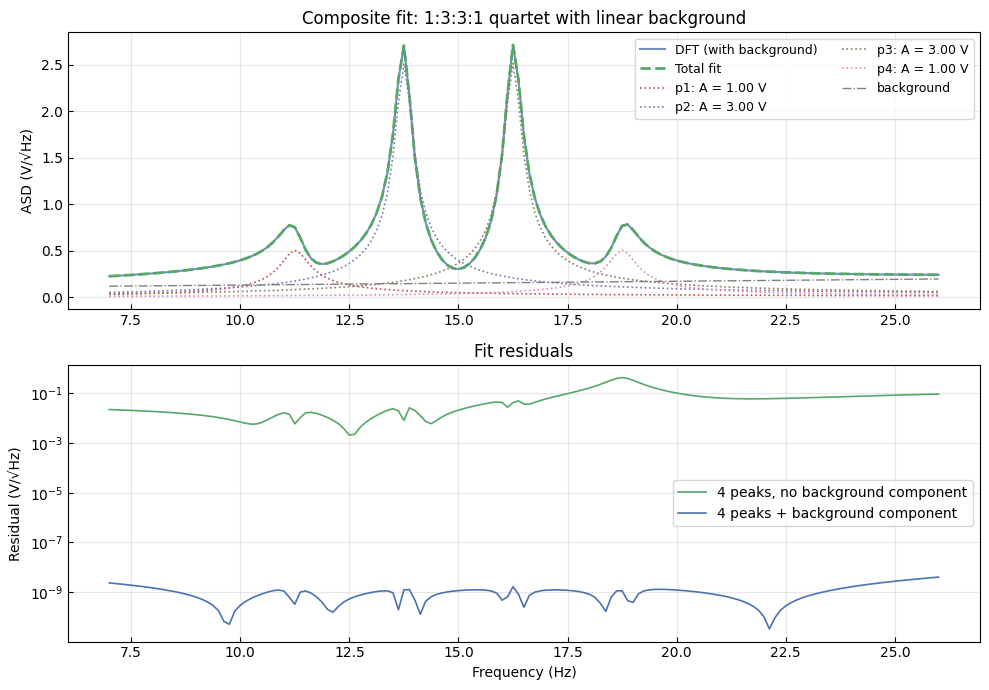

In [2]:
# Composite fit: four Lorentzian peaks, with and without spectral background
cfg        = fourier.dft_config
correction = DFTCorrection(DFTCorrectionMode.ALL, order=10)

lcomp    = SineFourier(cfg, correction)
bg_model = ModelBase.build_model(linear_complex)

composite    = CompositeModel([(f"p{k+1}", lcomp) for k in range(4)])
composite_bg = CompositeModel([(f"p{k+1}", lcomp) for k in range(4)] + [("bg", bg_model)])

MASK = (fourier.x >= 7.0) & (fourier.x <= 25.0)

def _peak_params_init():
    return {
        f"p{k+1}": SineFourier.make_params(
            amplitude_i=AIS[k] * 1.1, amplitude_q=0.0,
            frequency=FREQS[k] * 1.02, decay=DECAYS[k] * 1.1,
            frequency_min=FREQS[k] - J * 0.4, frequency_max=FREQS[k] + J * 0.4,
        )
        for k in range(4)
    }

def _sub_params(result, prefix):
    sub = lmfit.Parameters()
    for name in SineFourier.PARAM_NAMES:
        p = result.params[f"{prefix}_{name}"]
        sub.add(name, value=p.value)
        sub[name].stderr = p.stderr
    return sub

fourier_bg = FourierSeries(
    x=fourier.x, y=fourier.y + BG_INTERCEPT + BG_SLOPE * fourier.x,
    dft_config=fourier.dft_config,
)

result_clean = composite.fit(fourier,    composite.make_params(**_peak_params_init()), mask=MASK)
result_nobg  = composite.fit(fourier_bg, composite.make_params(**_peak_params_init()), mask=MASK)
result_bg    = composite_bg.fit(
    fourier_bg,
    composite_bg.make_params(
        **_peak_params_init(),
        bg=bg_model.make_params(
            real_intercept=0.0, imag_intercept=0.0,
            real_slope=0.0, imag_slope=0.0,
        ),
    ),
    mask=MASK,
)

def _ratios(result):
    amps = [SineFourier.amplitude(_sub_params(result, f"p{k+1}")) for k in range(4)]
    return [a / amps[0] for a in amps]

print(f"{'':20}  {'p1':>6}  {'p2':>6}  {'p3':>6}  {'p4':>6}")
print("-" * 48)
print(f"{'True 1:3:3:1':20}  {'1.000':>6}  {'3.000':>6}  {'3.000':>6}  {'1.000':>6}")
print(f"{'Clean fit':20}  " + "  ".join(f"{r:6.3f}" for r in _ratios(result_clean)))
print(f"{'Background fit':20}  " + "  ".join(f"{r:6.3f}" for r in _ratios(result_bg)))

# Figure
x    = fourier_bg.x
zoom = (x >= 7) & (x <= 26)

y_fit_nobg = composite.eval(result_nobg.params, x)
y_fit_bg   = composite_bg.eval(result_bg.params, x)

sub_peaks = [_sub_params(result_bg, f"p{k+1}") for k in range(4)]
y_peaks   = [lcomp.eval(sub_peaks[k], x) for k in range(4)]

bg_p = result_bg.params
y_bg = linear_complex(
    x,
    bg_p["bg_real_intercept"].value, bg_p["bg_imag_intercept"].value,
    bg_p["bg_real_slope"].value,     bg_p["bg_imag_slope"].value,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(x[zoom], np.abs(fourier_bg.y[zoom]), color="C0", alpha=0.8, lw=1.5,
             label="DFT (with background)")
axes[0].plot(x[zoom], np.abs(y_fit_bg[zoom]), color="C1", lw=2, ls="--", label="Total fit")
for k, yp in enumerate(y_peaks):
    axes[0].plot(x[zoom], np.abs(yp[zoom]), lw=1.2, ls=":", color=f"C{k+2}",
                 label=f"p{k+1}: A = {SineFourier.amplitude(sub_peaks[k]):.2f} V")
axes[0].plot(x[zoom], np.abs(y_bg[zoom]), color="gray", lw=1.0, ls="-.", label="background")
axes[0].set_ylabel("ASD (V/√Hz)")
axes[0].set_title("Composite fit: 1:3:3:1 quartet with linear background")
axes[0].legend(ncol=2, fontsize=9)

res_nobg = np.abs(fourier_bg.y - y_fit_nobg)
res_bg   = np.abs(fourier_bg.y - y_fit_bg)
axes[1].plot(x[zoom], res_nobg[zoom], color="C1", lw=1.2, label="4 peaks, no background component")
axes[1].plot(x[zoom], res_bg[zoom],   color="C0", lw=1.2, label="4 peaks + background component")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Residual (V/√Hz)")
axes[1].set_title("Fit residuals")
axes[1].semilogy()
axes[1].legend()

plt.tight_layout()
plt.savefig(f"figures/05_composite_model_fig01.svg", bbox_inches="tight")
plt.show()

## Precision and Cramér–Rao bounds

For a composite of $K$ decaying sinusoids in white noise $\sigma^2$, the Fisher information matrix is

$$\mathbf{I} = \frac{1}{\sigma^2}\,\mathbf{J}^\top \mathbf{J}, \qquad J_{nk} = \frac{\partial x_n}{\partial \theta_k},$$

where $\boldsymbol{\theta} = (a_{i,1},\, a_{q,1},\, f_1,\, \gamma_1,\, \ldots)$ collects all 16 parameters and the Jacobian is evaluated at the true values. For well-separated lines $\mathbf{I}$ is approximately block-diagonal (one $4\times 4$ block per peak), but overlapping Lorentzian tails introduce off-diagonal coupling that loosens the bound relative to independent single-peak fits. The CRB is $(\mathbf{I}^{-1})_{kk}$; amplitude bounds follow by propagating the $(a_i, a_q)$ covariance block.

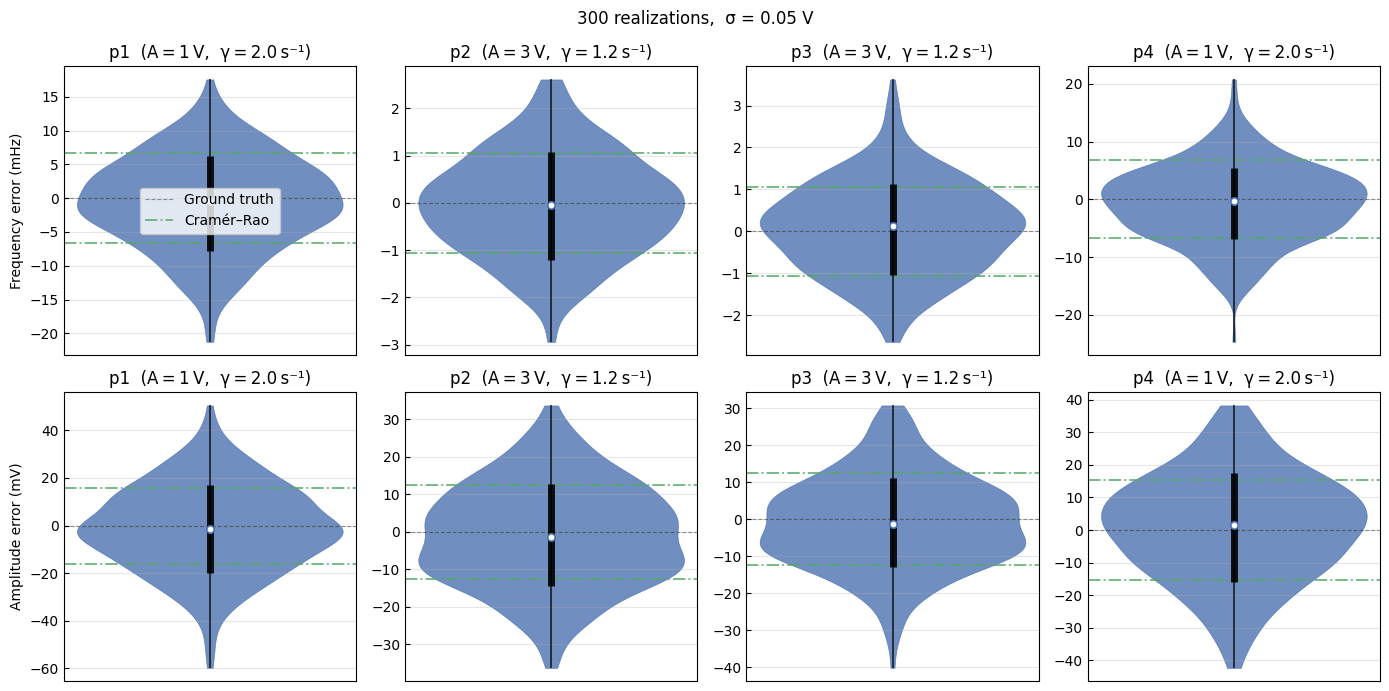

                                p1          p2          p3          p4
----------------------------------------------------------------------
CRB  freq (mHz)              6.650       1.061       1.061       6.755
     amp (mV)               15.936      12.466      12.443      15.393
----------------------------------------------------------------------
RMSE freq (mHz)              6.825       1.064       1.087       6.625
     amp (mV)               18.220      13.484      12.381      16.255
----------------------------------------------------------------------
Fit σ freq (mHz)             6.570       1.032       1.018       6.687
      amp (mV)              15.939      12.198      12.097      15.263


In [3]:
# Monte Carlo validation and Cramér–Rao bound
from helpers import violin_panel

params_crb = lmfit.Parameters()
for k in range(4):
    for name, val in zip(("ai", "aq", "f", "g"), [AIS[k], AQS[k], FREQS[k], DECAYS[k]]):
        params_crb.add(f"{name}_{k}", value=val)

def _composite_td(t, *p):
    return sum(Sinusoid.eval(t, p[4*k], p[4*k+1], p[4*k+2], p[4*k+3]) for k in range(4))

crb_vals = cramer_rao_bound(_composite_td, params_crb, t, NOISE_STD)

# aq = 0 → amplitude CRB = sqrt(Cov(a_i, a_i))
crb_freq = [np.sqrt(crb_vals[f"f_{k}"]) for k in range(4)]
crb_amp  = [np.sqrt(crb_vals[f"ai_{k}"]) for k in range(4)]

# Monte Carlo
rng_mc    = np.random.default_rng(seed=42)
freq_errs = [[] for _ in range(4)]
amp_errs  = [[] for _ in range(4)]

for _ in range(N_MC):
    sig_mc  = SignalSeries(x=t, y=_make_signal(noise_rng=rng_mc))
    four_mc = sig_mc.calculate_dft(
        norm=NormType.CFT, window=WindowType.RECTANGULAR,
        dft_range=DFTRange.SINGLE_SIDED, pad=1.0,
    )
    params_mc = composite.make_params(**{
        f"p{k+1}": SineFourier.make_params(
            amplitude_i=AIS[k], amplitude_q=0.0,
            frequency=FREQS[k], decay=DECAYS[k],
            frequency_min=FREQS[k] - J * 0.4, frequency_max=FREQS[k] + J * 0.4,
        )
        for k in range(4)
    })
    res_mc = composite.fit(four_mc, params_mc, mask=MASK)
    for k in range(4):
        sub = _sub_params(res_mc, f"p{k+1}")
        freq_errs[k].append(res_mc.params[f"p{k+1}_frequency"].value - FREQS[k])
        amp_errs[k].append(SineFourier.amplitude(sub) - AMPS[k])

# 2×4 violin grid: rows = (frequency, amplitude), columns = peaks
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for k in range(4):
    for row, (errs_raw, crb_val, ylabel) in enumerate([
        (freq_errs[k], crb_freq[k], "Frequency error (mHz)"),
        (amp_errs[k],  crb_amp[k],  "Amplitude error (mV)"),
    ]):
        ax    = axes[row, k]
        errs  = [e * 1e3 for e in errs_raw]
        crb_v = crb_val * 1e3
        show_legend = (k == 0 and row == 0)
        show_ylabel = (k == 0)
        violin_panel(ax, [errs], crb=crb_v,
                     ylabel=ylabel if show_ylabel else None,
                     title=f"p{k+1}  (A = {AMPS[k]:.0f} V,  γ = {DECAYS[k]:.1f} s⁻¹)",
                     legend=show_legend)

plt.suptitle(f"{N_MC} realizations,  σ = {NOISE_STD} V")
plt.tight_layout()
plt.savefig(f"figures/05_composite_model_fig02.svg", bbox_inches="tight")
plt.show()

# Summary table: CRB / MC RMSE / fit stderr
def _rmse(errs):
    return float(np.sqrt(np.mean(np.array(errs) ** 2)))

freq_se_fit = [res_mc.params[f"p{k+1}_frequency"].stderr for k in range(4)]
amp_se_fit  = [SineFourier.amplitude_stderr(_sub_params(res_mc, f"p{k+1}")) for k in range(4)]

cols = "  ".join(f"{'p'+str(k+1):>10}" for k in range(4))
hdr  = f"{'':22}  {cols}"
sep  = "-" * len(hdr)
print(hdr); print(sep)
print(f"{'CRB  freq (mHz)':22}  " + "  ".join(f"{crb_freq[k]*1e3:>10.3f}" for k in range(4)))
print(f"{'     amp (mV)':22}  "   + "  ".join(f"{crb_amp[k]*1e3:>10.3f}" for k in range(4)))
print(sep)
print(f"{'RMSE freq (mHz)':22}  " + "  ".join(f"{_rmse(freq_errs[k])*1e3:>10.3f}" for k in range(4)))
print(f"{'     amp (mV)':22}  "   + "  ".join(f"{_rmse(amp_errs[k])*1e3:>10.3f}" for k in range(4)))
print(sep)
print(f"{'Fit σ freq (mHz)':22}  " + "  ".join(f"{(se or 0)*1e3:>10.3f}" for se in freq_se_fit))
print(f"{'      amp (mV)':22}  "   + "  ".join(f"{se*1e3:>10.3f}" for se in amp_se_fit))

## Summary

- `CompositeModel` recovers the 1:3:3:1 amplitude ratios from four overlapping Lorentzian lines; the recovered peak spacings give the true J-coupling $J = 2.5$ Hz.
- When a spectral background is present but not modelled, residuals are dominated by the baseline and amplitude ratios are biased; adding a `linear_complex` background component restores both.
- The corrected composite estimator approaches the Cramér–Rao bound; outer peaks ($A = 1$ V) have proportionally larger uncertainty than inner peaks ($A = 3$ V), consistent with the $\text{CRB} \propto A^{-1}$ scaling.